In [1]:
#all installs here
!pip install pandas


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
#all imports here

import pandas as pd
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score


In [2]:
train = pd.read_csv("dataset/train.csv")
test = pd.read_csv("dataset/test.csv")


In [3]:
train.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


In [4]:
train.shape

(77299, 11)

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          77299 non-null  int64  
 1   geohash        77299 non-null  object 
 2   day            77299 non-null  int64  
 3   timestamp      77299 non-null  object 
 4   demand         77299 non-null  float64
 5   RoadType       76699 non-null  object 
 6   NumberofLanes  77299 non-null  int64  
 7   LargeVehicles  77299 non-null  object 
 8   Landmarks      77299 non-null  object 
 9   Temperature    74804 non-null  float64
 10  Weather        76502 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 6.5+ MB


In [6]:
train.describe() #data in demand is normalised

,Index,day,demand,NumberofLanes,Temperature
count,77299.000000,77299.000000,7.729900e+04,77299.000000,74804.000000
mean,38649.000000,48.101838,9.394238e-02,2.014334,16.405354
std,22314.443566,0.302438,1.421905e-01,0.904665,7.359835
min,0.000000,48.000000,6.245650e-07,1.000000,-14.935097
25%,19324.500000,48.000000,1.822723e-02,1.000000,11.430473
50%,38649.000000,48.000000,4.775994e-02,2.000000,16.382587
75%,57973.500000,48.000000,1.085951e-01,3.000000,21.298833
max,77298.000000,49.000000,1.000000e+00,5.000000,48.251433


In [7]:
train.median(numeric_only=True)

Index            38649.000000
day                 48.000000
demand               0.047760
NumberofLanes        2.000000
Temperature         16.382587
dtype: float64

In [8]:
train.mode().iloc[0]

Index                      0
geohash               qp03mg
day                     48.0
timestamp                2:0
demand                   1.0
RoadType         Residential
NumberofLanes            1.0
LargeVehicles    Not Allowed
Landmarks                Yes
Temperature       -14.935097
Weather                Sunny
Name: 0, dtype: object

In [9]:
train.isnull().sum()

Index               0
geohash             0
day                 0
timestamp           0
demand              0
RoadType          600
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      2495
Weather           797
dtype: int64

In [10]:

test.isnull().sum()

Index               0
geohash             0
day                 0
timestamp           0
RoadType          324
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      1349
Weather           431
dtype: int64

In [11]:
train.duplicated().sum()

np.int64(0)

In [12]:
train.nunique()

Index            77299
geohash           1249
day                  2
timestamp           96
demand           76715
RoadType             3
NumberofLanes        5
LargeVehicles        2
Landmarks            2
Temperature      74804
Weather              4
dtype: int64

In [13]:
train['RoadType'] = train['RoadType'].fillna(train['RoadType'].mode()[0])
train['Weather'] = train['Weather'].fillna(train['Weather'].mode()[0])
train['Temperature'] = train['Temperature'].fillna(train['Temperature'].median())


In [14]:
time_split = train['timestamp'].str.split(':', expand=True)

train['hour'] = time_split[0].astype(int)
train['minute'] = time_split[1].astype(int)



In [15]:

# Temperature → category
train['Temp_Category'] = pd.cut(train['Temperature'], bins=[0,15,30,45], labels=['cold','mild','hot'])
# Geohash → location
train['location'] = train['geohash'].str[:5]
# Drop raw columns
train.drop(['timestamp','Temperature','geohash'], axis=1, inplace=True)

In [16]:
from sklearn.preprocessing import LabelEncoder

cols = ['RoadType', 'LargeVehicles', 'Landmarks', 'Weather', 'Temp_Category', 'location']

le_dict = {}  # store encoders for each column

for col in cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])
    le_dict[col] = le

In [17]:
train = train.drop(['Index'], axis=1)

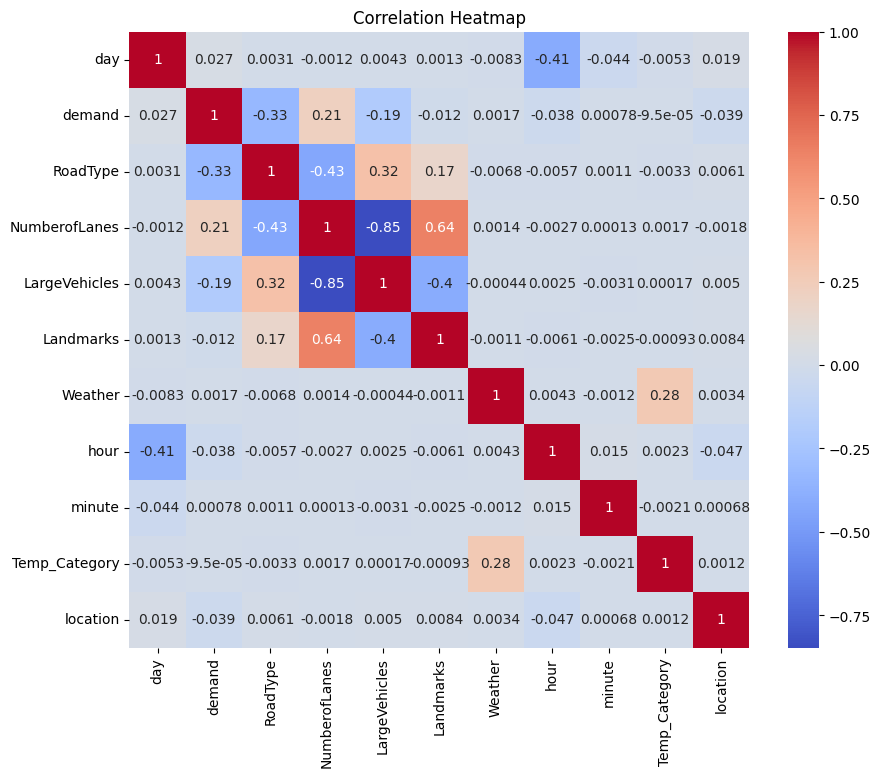

In [18]:
plt.figure(figsize=(10,8))
corr = train.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [19]:
corr_target = train.corr()['demand'].sort_values(ascending=False)
print(corr_target)



demand           1.000000
NumberofLanes    0.214148
day              0.026807
Weather          0.001718
minute           0.000783
Temp_Category   -0.000095
Landmarks       -0.011527
hour            -0.037806
location        -0.038738
LargeVehicles   -0.193623
RoadType        -0.333496
Name: demand, dtype: float64


In [20]:
train = train.drop(['LargeVehicles'], axis=1)

In [21]:
X = train.drop('demand', axis=1)
y = train['demand']

In [22]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_preds = lr.predict(X_val)

lr_r2 = r2_score(y_val, lr_preds)
print("Linear Regression R2:", lr_r2)
print("Competition Score:", max(0, 100*lr_r2))

Linear Regression R2: 0.121999545960357
Competition Score: 12.1999545960357


In [24]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_val)

r2 = r2_score(y_val, preds)
print(r2)
print("Competition Score:", max(0, 100*r2))

0.7526254505794877
Competition Score: 75.26254505794877
